In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ipl.csv')
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_result,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 22,2025","Eden Gardens, Kolkata",KKR,RCB,League,RCB,Bowl,174.0,8.0,...,completed,RCB,NaN,7,22.0,Krunal Pandya,Virat Kohli,59.0,Krunal Pandya,3--29
1,2,"March 23,2025","Rajiv Gandhi International Stadium, Hyderabad",SRH,RR,League,RR,Bowl,286.0,6.0,...,completed,SRH,44,NaN,0.0,Ishan Kishan,Ishan Kishan,106.0,Tushar Deshpande,3--44
2,3,"March 23,2025","MA Chidambaram Stadium, Chennai",CSK,MI,League,CSK,Bowl,155.0,9.0,...,completed,CSK,NaN,4,5.0,Noor Ahmad,Rachin Ravindra,65.0,Noor Ahmad,4--18
3,4,"March 24,2025","ACA-VDCA Cricket Stadium, Vishakhapatnam",DC,LSG,League,DC,Bowl,209.0,8.0,...,completed,DC,NaN,1,3.0,Ashutosh Sharma,Nicholas Pooran,75.0,Mitchell Starc,3--42
4,5,"March 25,2025","Narendra Modi Stadium, Ahmedabad",GT,PBKS,League,GT,Bowl,243.0,5.0,...,completed,PBKS,11,NaN,0.0,Shreyas Iyer,Shreyas Iyer,97.0,Sai Kishore,3--30


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             74 non-null     int64  
 1   date                 74 non-null     object 
 2   venue                74 non-null     object 
 3   team1                74 non-null     object 
 4   team2                74 non-null     object 
 5   stage                74 non-null     object 
 6   toss_winner          73 non-null     object 
 7   toss_decision        74 non-null     object 
 8   first_ings_score     73 non-null     float64
 9   first_ings_wkts      73 non-null     float64
 10  second_ings_score    72 non-null     float64
 11  second_ings_wkts     72 non-null     float64
 12  match_result         74 non-null     object 
 13  match_winner         71 non-null     object 
 14  wb_runs              34 non-null     object 
 15  wb_wickets           38 non-null     objec

In [5]:
print(f"Total Matches: {df.shape[0]} \nTotal Details: {df.shape[1]}")

Total Matches: 74 
Total Details: 22


In [6]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,1
toss_decision,0
first_ings_score,1
first_ings_wkts,1


1. Most Matches Won:

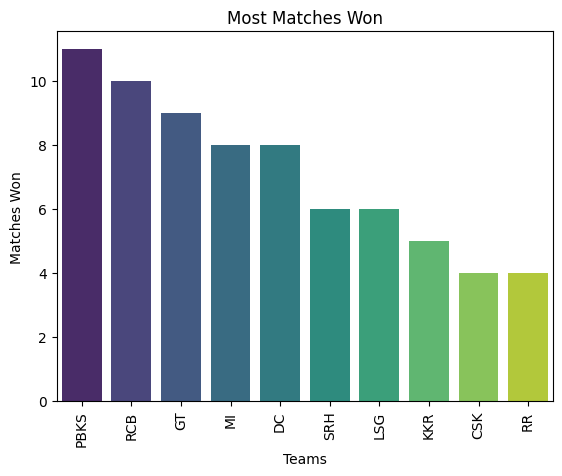

In [7]:
match_wins = df['match_winner'].value_counts()
sns.barplot(x=match_wins.index, y=match_wins.values, palette='viridis')
plt.xlabel('Teams')
plt.ylabel('Matches Won')
plt.xticks(rotation=90)
plt.title('Most Matches Won')
plt.show()

2. Toss Decsion Trend:

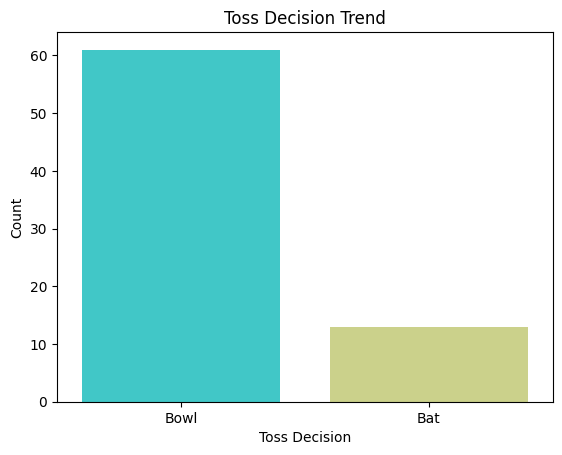

In [8]:
sns.countplot(x='toss_decision', data=df, palette='rainbow')
plt.xlabel('Toss Decision')
plt.ylabel('Count')
plt.title('Toss Decision Trend')
plt.show()

3. Toss Wins vs Match Wins

In [9]:
df[df['toss_winner']==df['match_winner']].shape[0]
count = df[df['toss_winner']==df['match_winner']]['match_id'].count()
percent = (count * 100)/df.shape[0]
percent.round(2)

np.float64(56.76)

4. Win By Runs vs Wickets

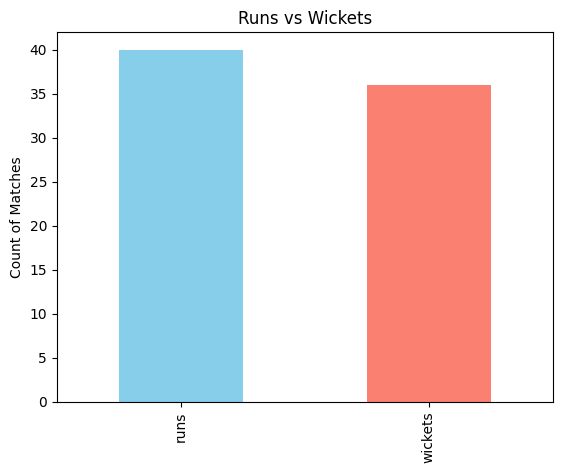

In [10]:
runs = df['wb_runs'].isna().sum()
wickets = df['wb_wickets'].isna().sum()

missing_series = pd.Series({'runs': runs, 'wickets': wickets})
missing_series.plot(kind='bar', color=['skyblue', 'salmon'])

plt.title('Runs vs Wickets')
plt.ylabel('Count of Matches')
plt.show()


5. Most Player of the Matches:

In [11]:
count = df['player_of_the_match'].value_counts().head(10)

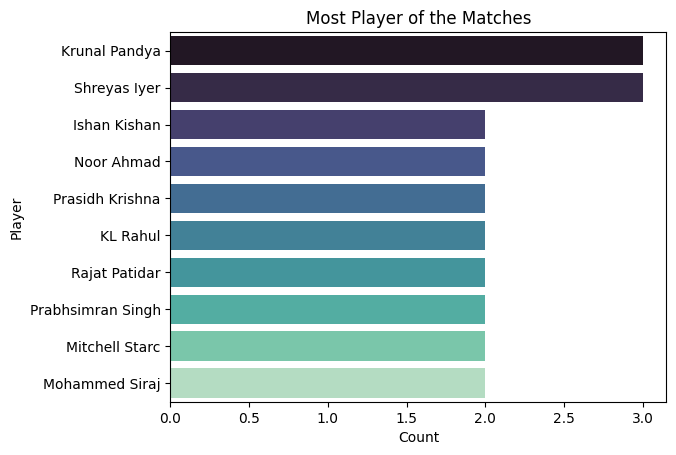

In [12]:
sns.barplot(x = count.values, y= count.index, palette='mako')
plt.xlabel('Count')
plt.ylabel('Player')
plt.title('Most Player of the Matches')
plt.show()

6. Most Top Scores

In [13]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

,highscore
top_scorer,
Nicholas Pooran,293.0
Virat Kohli,269.0


Text(0.5, 1.0, 'Most Top Scores')

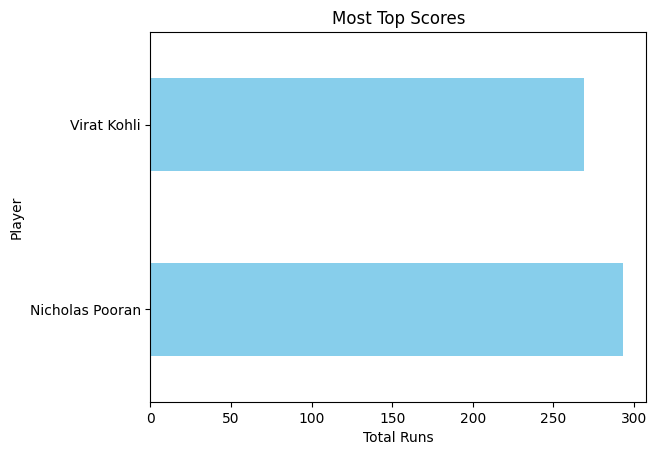

In [14]:
high.plot(kind='barh', color='skyblue')
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.title('Most Top Scores')

7. Best Bowling Figures:

In [22]:
# 1. Safely split the strings
df['highest_wickets'] = df['best_bowling_figure'].astype(str).str.split('--').str[0]

# 2. Convert to integer while handling 'nan' or errors gracefully
df['highest_wickets'] = pd.to_numeric(df['highest_wickets'], errors='coerce').astype('Int64')
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers

,highest_wickets
best_bowling,
Prasidh Krishna,13
Arshdeep Singh,11
Noor Ahmad,11
Josh Hazlewood,10
Krunal Pandya,10
Mitchell Starc,8
Harshal Patel,8
Jasprit Bumrah,8
Yuzvendra Chahal,8


Text(0.5, 1.0, 'Most Top Wickets')

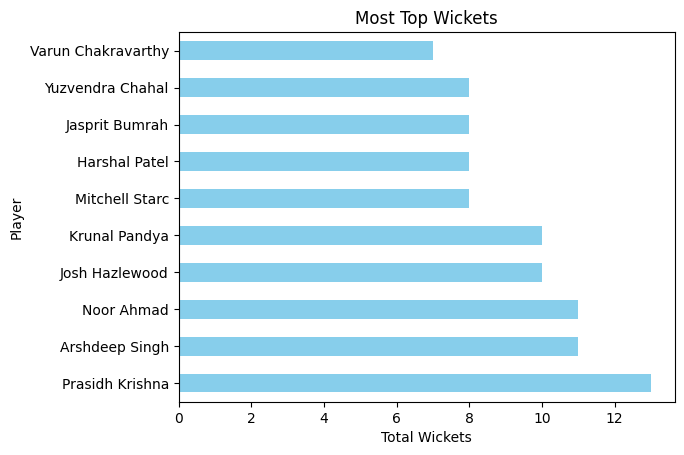

In [23]:
top_bowlers.plot(kind='barh', color='skyblue')
plt.xlabel('Total Wickets')
plt.ylabel('Player')
plt.title('Most Top Wickets')

8. Most Matches at Venue:

In [24]:
venue_count = df['venue'].value_counts().head(10)
venue_count

,count
venue,
"Narendra Modi Stadium, Ahmedabad",9
"Ekana Cricket Stadium, Lucknow",8
"Eden Gardens, Kolkata",7
"Wankhede Stadium, Mumbai",7
"Arun Jaitley Stadium, Delhi",7
"Sawai Mansingh Stadium, Jaipur",7
"New PCA Cricket Stadium, Mullanpur",6
"Rajiv Gandhi International Stadium, Hyderabad",6
"MA Chidambaram Stadium, Chennai",6


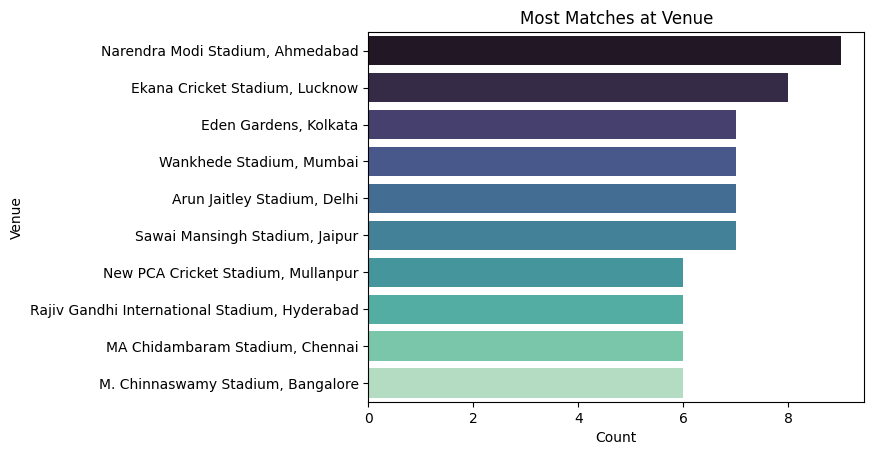

In [25]:
sns.barplot(x=venue_count.values, y=venue_count.index, palette='mako')
plt.xlabel('Count')
plt.ylabel('Venue')
plt.title('Most Matches at Venue')
plt.show()


9. Highest Win By Runs:

In [37]:
df['wb_runs'] = pd.to_numeric(df['wb_runs'], errors='coerce').astype('Int64')
margin = df.groupby('match_winner')['wb_runs'].max().sort_values(ascending=False).head(10)
margin.index[0]

'SRH'

10. Highest Individual Score:

In [41]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
26,Abhishek Sharma,141.0


11. Best Bowling Figure

In [43]:
df['highest_wickets'] = df['best_bowling_figure'].astype(str).str.split('--').str[0]

# 2. Convert to integer while handling 'nan' or errors gracefully
df['highest_wickets'] = pd.to_numeric(df['highest_wickets'], errors='coerce').astype('Int64')
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','highest_wickets']]


,best_bowling,highest_wickets
9,Mitchell Starc,5
15,Hardik Pandya,5
